# Trustworthy recidivism forecasting

**Question:** At supervision start, which people are most likely to have a new arrest within three years, so a hypothetical agency can prioritize voluntary support?

This notebook compares logistic regression, XGBoost, and TabICLv2 across predictive and economic performance, interpretability, stability, and fairness. The outcome is arrest, not inherent criminality; this analysis is unsuitable for adverse decisions.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'artifacts').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from recidivism.data import load_official_split
from recidivism.metrics import economic_value

split = load_official_split(ROOT / 'nij-challenge2021_full_dataset.csv')
metrics = pd.read_csv(ROOT / 'artifacts/model_metrics.csv')
fairness = pd.read_csv(ROOT / 'artifacts/fairness_by_group.csv')
gaps = pd.read_csv(ROOT / 'artifacts/fairness_gaps.csv')
importance = pd.read_csv(ROOT / 'artifacts/permutation_importance.csv')
predictions = pd.read_csv(ROOT / 'artifacts/test_predictions.csv')
print(f'Train: {len(split.X_train):,} | Test: {len(split.X_test):,} | Features: {split.X_train.shape[1]}')

Train: 18,028 | Test: 7,807 | Features: 29


## Design and leakage control

The official `Training_Sample` flag defines the untouched test set. Only fields available when supervision begins are eligible. Post-release violations, tests, programs, employment, and residence changes are excluded. Race, gender, and Residence PUMA are excluded from scoring; race and gender remain in the audit layer.

The white-box pipeline imputes and one-hot encodes fields, then fits regularized logistic regression. XGBoost uses the same prepared matrix. TabICLv2 receives deterministic one-column-per-field encoding and applies pretrained in-context inference. The complete training and audit implementation is in `scripts/train_evaluate.py`.

In [2]:
# Change to True to rebuild every artifact (a CUDA GPU is recommended for TabICLv2).
RUN_TRAINING = False
if RUN_TRAINING:
    import subprocess
    subprocess.run([sys.executable, str(ROOT / 'scripts/train_evaluate.py')], cwd=ROOT, check=True)

## Predictive performance

In [3]:
cols = ['model','roc_auc','average_precision','brier','log_loss','ece_10','fit_predict_seconds']
metrics[cols].round(4).sort_values('brier')

,model,roc_auc,average_precision,brier,log_loss,ece_10,fit_predict_seconds
0,tabicl,0.7336,0.7719,0.2039,0.5932,0.0197,7.1253
1,xgboost,0.7299,0.7686,0.2054,0.5969,0.0118,3.0446
2,logistic,0.7295,0.7691,0.2055,0.5969,0.0132,0.5895


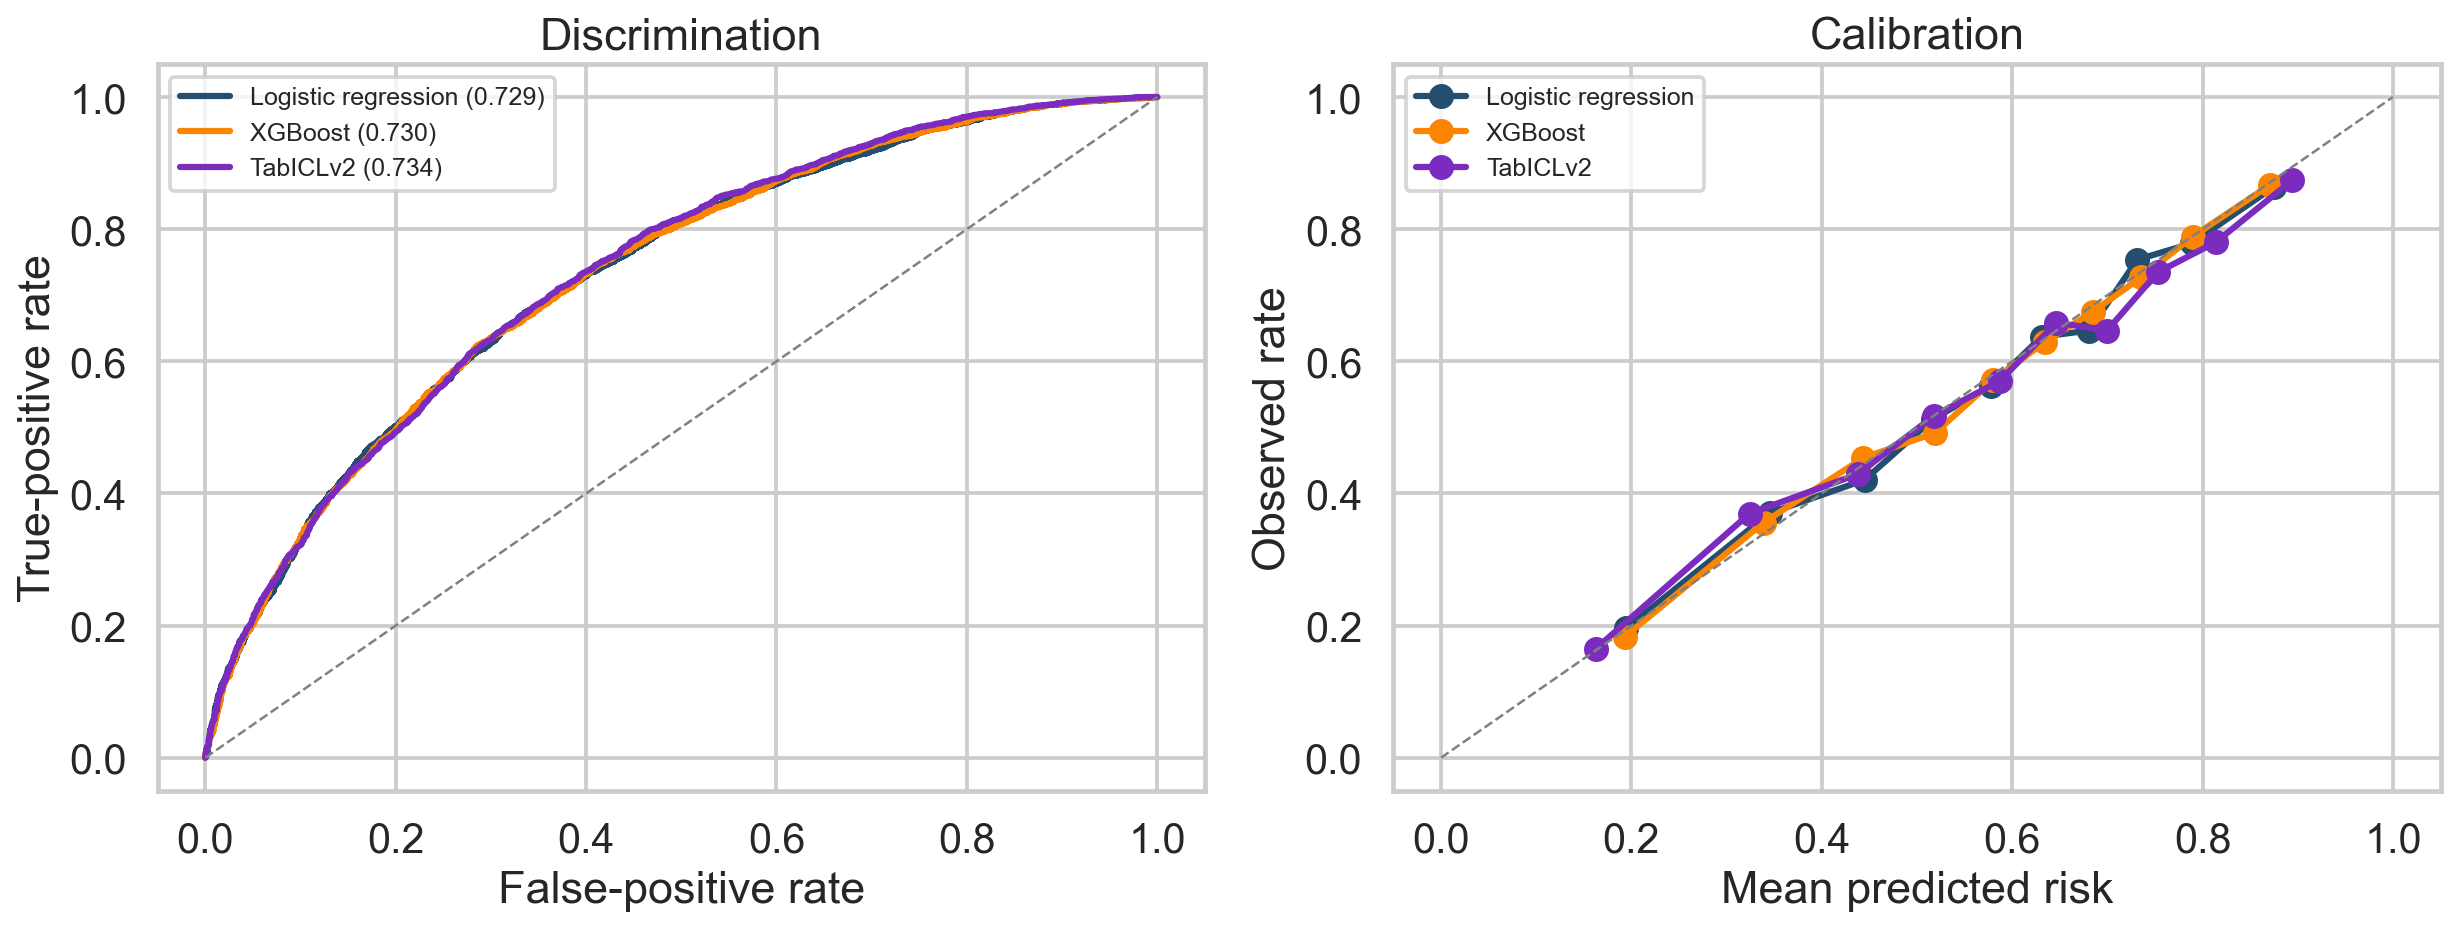

In [4]:
display(Image(filename=str(ROOT / 'artifacts/figures/performance_calibration.png'), width=1000))

TabICLv2 has the best held-out Brier score and discrimination, but its gain over XGBoost is small. XGBoost has the lowest calibration error. Overlapping bootstrap intervals caution against treating the rank order as decisive.

In [5]:
intervals = json.loads((ROOT / 'artifacts/bootstrap_intervals.json').read_text())
pd.concat({m: pd.DataFrame(v).T for m, v in intervals.items()}, names=['model','metric']).round(4)

low    high
model    metric                           
logistic roc_auc            0.7177  0.7409
         average_precision  0.7549  0.7831
         brier              0.2016  0.2096
xgboost  roc_auc            0.7185  0.7408
         average_precision  0.7544  0.7822
         brier              0.2014  0.2094
tabicl   roc_auc            0.7213  0.7446
         average_precision  0.7578  0.7860
         brier              0.1997  0.2086

## Economic scenario

In [6]:
rows = []
for model in ['logistic','xgboost','tabicl']:
    rows.append({'model': model, **economic_value(predictions.actual, predictions[f'p_{model}'], capacity=.20, intervention_cost=5_000, event_cost=50_000, effectiveness=.20)})
pd.DataFrame(rows).round(3)

,model,capacity,selected,captured_events,recall_at_capacity,precision_at_capacity,assumed_gross_benefit,assumed_program_cost,assumed_net_value
0,logistic,0.2,1561,1282,0.286,0.821,12820000.0,7805000.0,5015000.0
1,xgboost,0.2,1561,1292,0.288,0.828,12920000.0,7805000.0,5115000.0
2,tabicl,0.2,1561,1291,0.288,0.827,12910000.0,7805000.0,5105000.0


The dollar result is a transparent scenario, not a causal estimate. The observational data cannot show whether a specific intervention prevents arrests.

## Interpretability

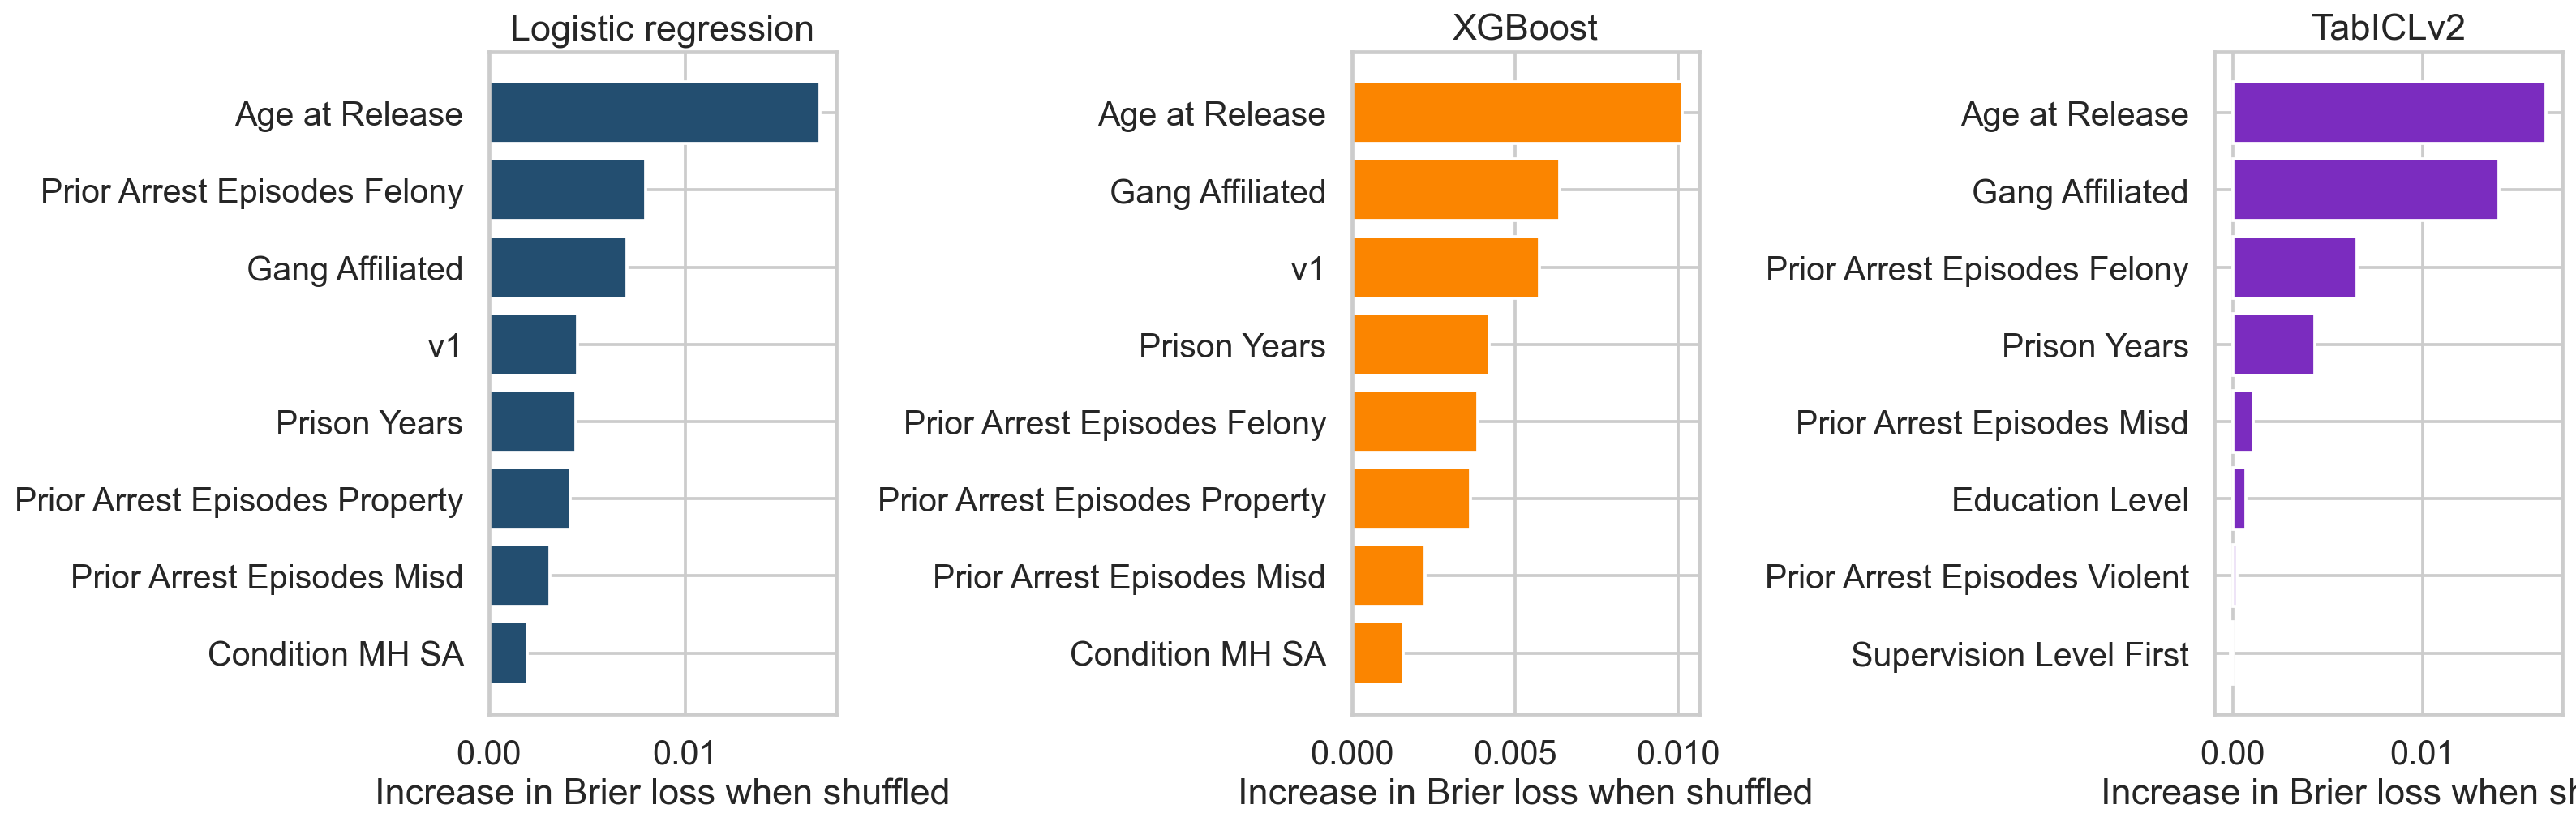

In [7]:
display(Image(filename=str(ROOT / 'artifacts/figures/feature_importance.png'), width=1100))

Permutation importance measures the held-out increase in Brier loss when a field is shuffled. Age at release, gang affiliation, prior felony arrests, and prison tenure recur across models. These associations are not causal explanations.

## Fairness

In [8]:
gaps.round(4).sort_values(['attribute','fpr_gap'])

,model,attribute,demographic_parity_gap,equal_opportunity_gap,fpr_gap,brier_gap
2,xgboost,Gender,0.1103,0.0264,0.1066,0.0027
0,logistic,Gender,0.1307,0.0528,0.1207,0.0006
4,tabicl,Gender,0.2658,0.1677,0.2729,0.0043
3,xgboost,Race,0.0304,0.0120,0.0424,0.0066
1,logistic,Race,0.0417,0.0171,0.0616,0.0085
5,tabicl,Race,0.0442,0.0161,0.0685,0.0077


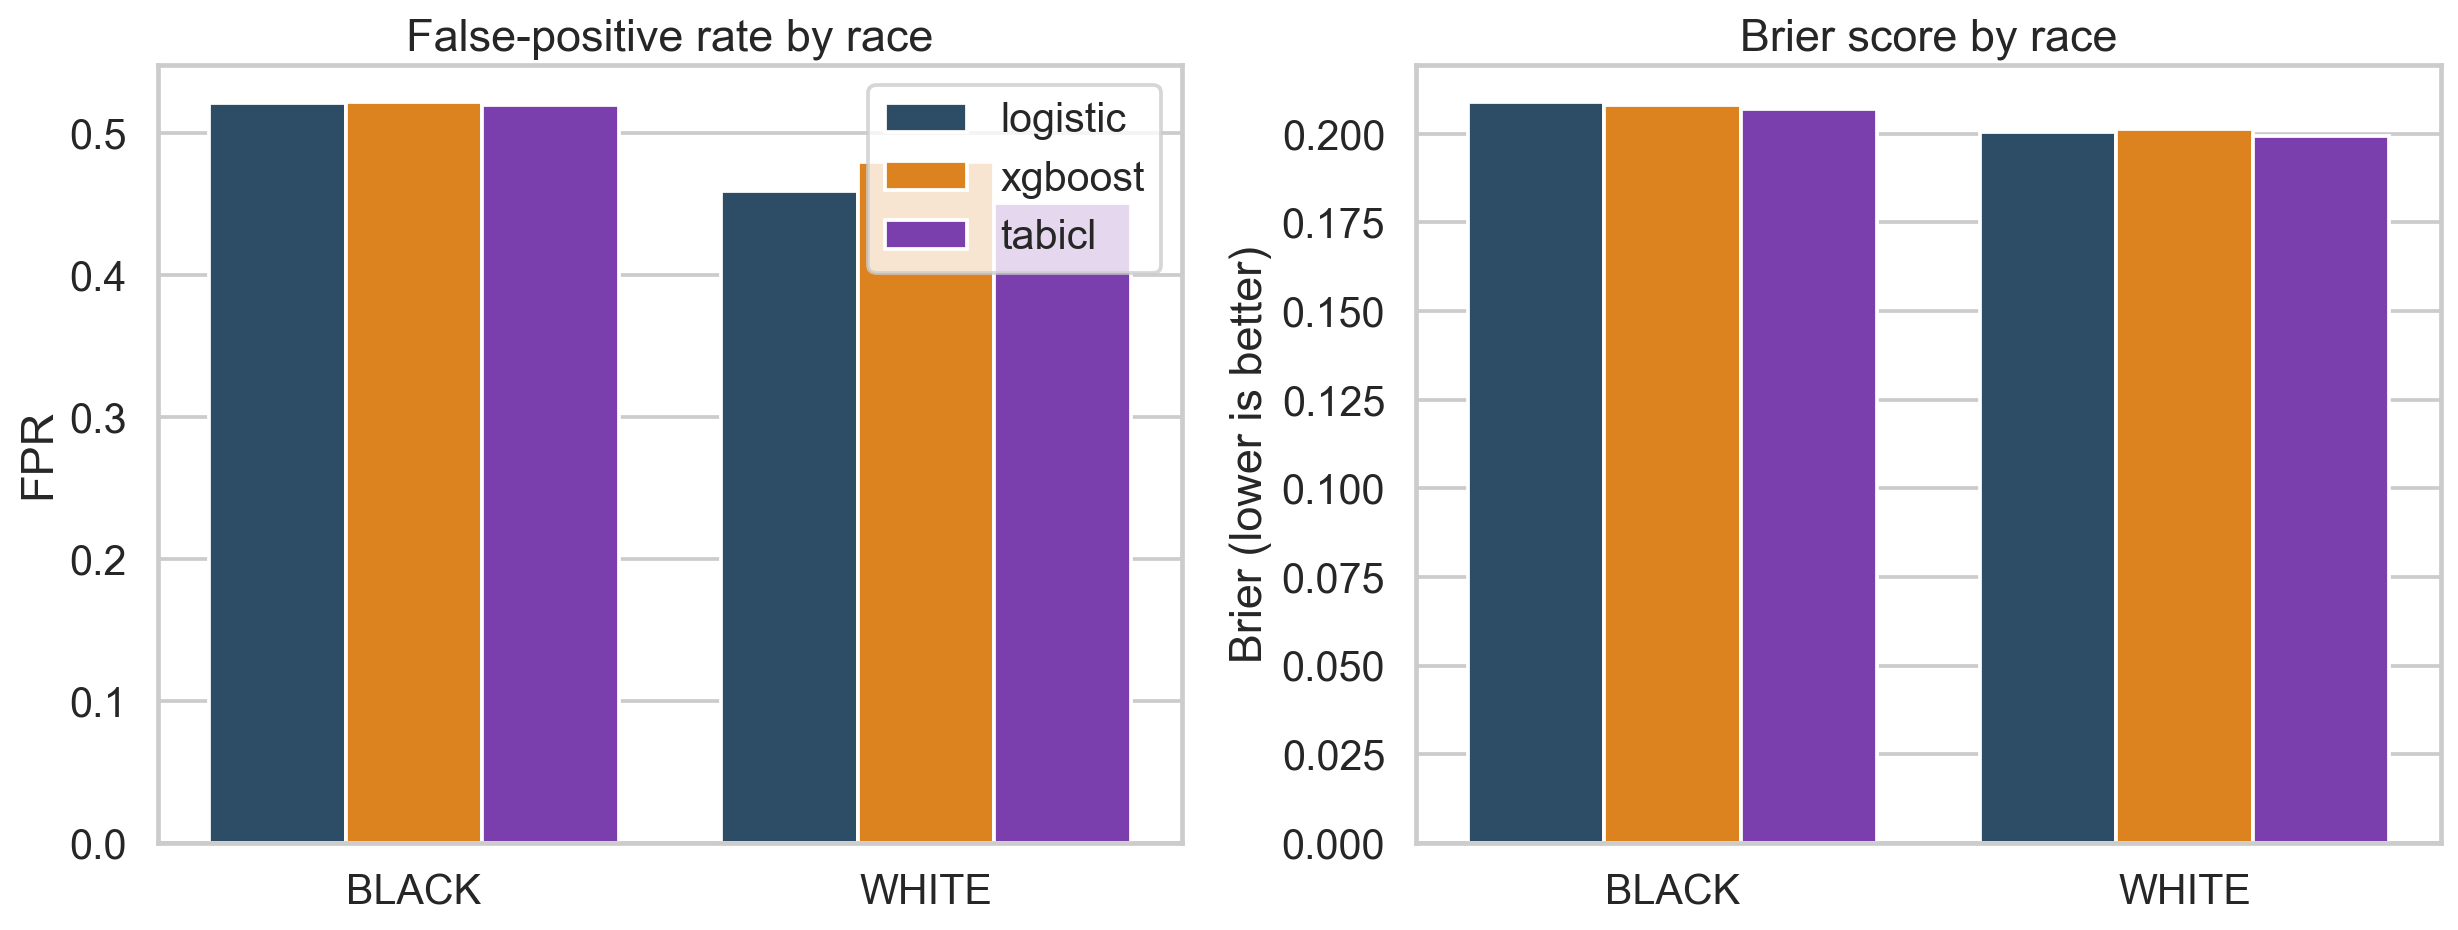

In [9]:
display(Image(filename=str(ROOT / 'artifacts/figures/race_fairness.png'), width=1000))

At threshold 0.5, XGBoost has the smallest observed race and gender false-positive-rate gaps. Fairness depends on the operating threshold and use case. Attribute exclusion does not remove proxy, label, or historical bias.

## Stability

In [10]:
stability = json.loads((ROOT / 'artifacts/stability.json').read_text())
pd.DataFrame(stability).T.round(4)

,all_features_shuffled_mae,all_features_shuffled_rank_correlation,bootstrap_brier_interval_width,bootstrap_auc_interval_width
logistic,0.2102,-0.0004,0.0081,0.0232
xgboost,0.2046,-0.0132,0.0079,0.0223
tabicl,0.2248,0.0017,0.0089,0.0233


The models have similar bootstrap interval widths. A temporal stability test is impossible because no suitable cohort date is available; later-cohort validation is a deployment gate.

## Recommendation

Pilot **XGBoost** for benefit-only service allocation, with logistic regression as a transparent challenger. It is nearly tied on predictive performance, calibrates best, runs cheaply, and has smaller observed subgroup gaps. Keep the system in shadow mode until a prospective study demonstrates benefit without unacceptable subgroup harm.